# Seasonal Influenza Parameter Inference via MCMC

This notebook performs rolling-window Bayesian inference on Italian Influenza-like Illness (ILI) data using a pre-trained Physics-Informed Neural Network (SIR-INN) combined with MCMC.

Posterior samples are then propagated forward to generate probabilistic forecasts in notebook `03_forecast.ipynb`.

## 1. Setup and environment

We load the required libraries and project modules.
The repository root is added to the Python path to enable local imports.

In [ ]:
# Fix compatibility issue with pymcmcstat on Python 3.12
import pymcmcstat, os

filepath = os.path.join(os.path.dirname(pymcmcstat.__file__), 'plotting/utilities.py')

with open(filepath, 'r') as f:
    content = f.read()

content = content.replace('from scipy import pi, sin, cos', 'from numpy import pi, sin, cos')

with open(filepath, 'w') as f:
    f.write(content)

In [1]:
import sys
from pathlib import Path

# Add repository root to Python path
repo_root = Path().resolve().parent
sys.path.append(str(repo_root))

# Standard
import numpy as np
import torch
from torch import nn, load
import os

# Project modules
# Neural Network loader
from src.models.sir_inn import NN
# Data and inference utils
from src.data.data_loader import load_multiple_influenza_seasons, plot_observed_ili_seasons, load_train_data
from src.forecasting.inference import run_influcast_mcmc_inference,save_mcmc_chain_tails,plot_inferred_parameters,plot_inferred_R0,plot_training_set_with_parameters

## 2. Data: ILI incidence form italian seasonal influenza

We load weekly Italian influenza-like illness (ILI) incidence data. Then we visualize the observed ILI incidence for the seasons under consideration. These trajectories will be used as input data for parameter inference and probabilistic forecasting with SIR-INN.

In [2]:
seasons = load_multiple_influenza_seasons(
    seasons=["2023-2024", "2024-2025"]
)

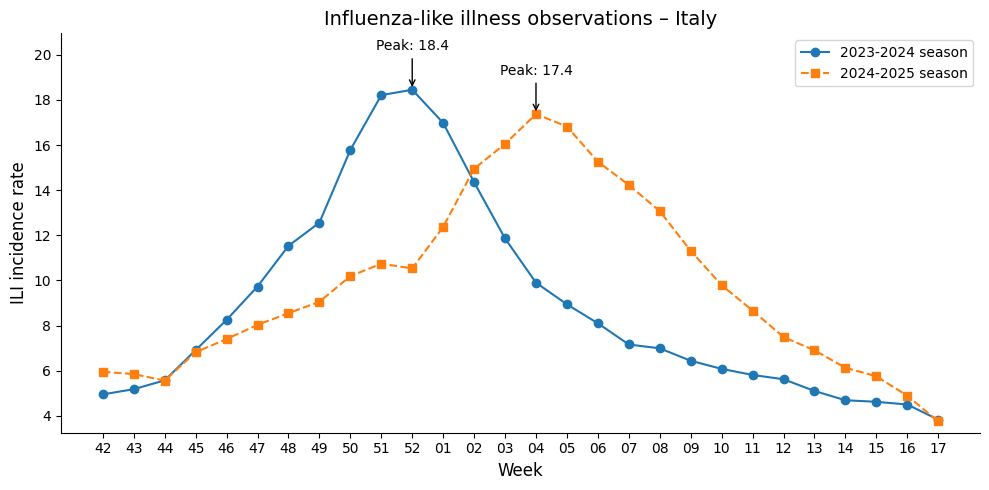

In [3]:
plot_observed_ili_seasons(seasons)

## 3. Parameter inference via rolling-window MCMC

We perform Bayesian parameter inference on the Influcast ILI observations using a rolling-window strategy.
At each epidemiological week, a short observation window is assimilated and a Markov Chain Monte Carlo (MCMC) procedure is employed to infer the epidemiological parameters of the SIR-INN model.

For each inference step (i.e., rolling window of length `observation_window_size = 5`), we estimate the posterior distributions of the SIR-based transition rates: the disease transmission rate $\beta$, the recovery rate $\gamma$, and the epidemic alignment time $\tau_0$ (i.e., the initial time at which we start to observe the data).
The basic reproduction number $R_0 = \beta / \gamma$ and the effective reproduction number $R_t= R_0 \cdot S(t)$ are then derived from the inferred parameters.

In the following, we report the posterior mean estimates of these quantities as a function of time (i.e., week), providing insight into the temporal evolution and stability of the inferred epidemiological dynamics.

### 3.1 Load the pretrained SIR-INN model

In [2]:
# The model approximates the continuous-time SIR dynamics
activation = nn.Tanh
dimensions = [3, 16, 32, 16, 3]
sir_inn = NN(activation=activation, dimensions=dimensions)
sir_inn.load_state_dict(torch.load("../checkpoints/SIR-INN_pretrained.pth", map_location='cpu'))

sir_inn.eval()

NN(
  (stack): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): Tanh()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=3, bias=True)
    (7): Sigmoid()
  )
)

### 3.2 Experimental setup

In [3]:
# Influenza season under study
season = '2023-2024' #'2023-2024' or '2024-2025'

# Folder of results
chains_dir = rf"../tmp_results/{season}" 

#Type of priors
priors = 'uniform'

# Length of rolling window of observations (weeks)
observation_window_size=5

### 3.3 Parameters inference step via MCMC

In [4]:
results_pinn = run_influcast_mcmc_inference(
    season=season,
    country="italia",
    dt_train=observation_window_size,
    output_dir=chains_dir,
    pinn_model = sir_inn,
    priors = priors,
    nsim=10000,
    seed=10
)

MCMC inference: 100%|███████████████████████████████████████████████████████████████████| 25/25 [03:57<00:00,  9.51s/it]


## 4. Inference visualization

### 4.1 Posterior distributions of inferred parameters

For each epidemiological week, we visualize the posterior distributions of the inferred parameters $\beta, \gamma, \tau_0, R_t$, and $R_0$ as boxplots.
The box spans the interquartile range (IQR), the orange line marks the weekly posterior median, and the dashed horizontal line represents the overall median across all weeks.

In [5]:
chains_dir = rf"../tmp_results/{season}/{priors}/" 

In [6]:
save_mcmc_chain_tails(
    path=chains_dir,
    dt_train=observation_window_size,
    pinn_model=sir_inn,
    sample_strategy="tail",
    nsim=10000
)

File saved in: ../tmp_results/2023-2024/uniform/mcmc_distributions.pkl


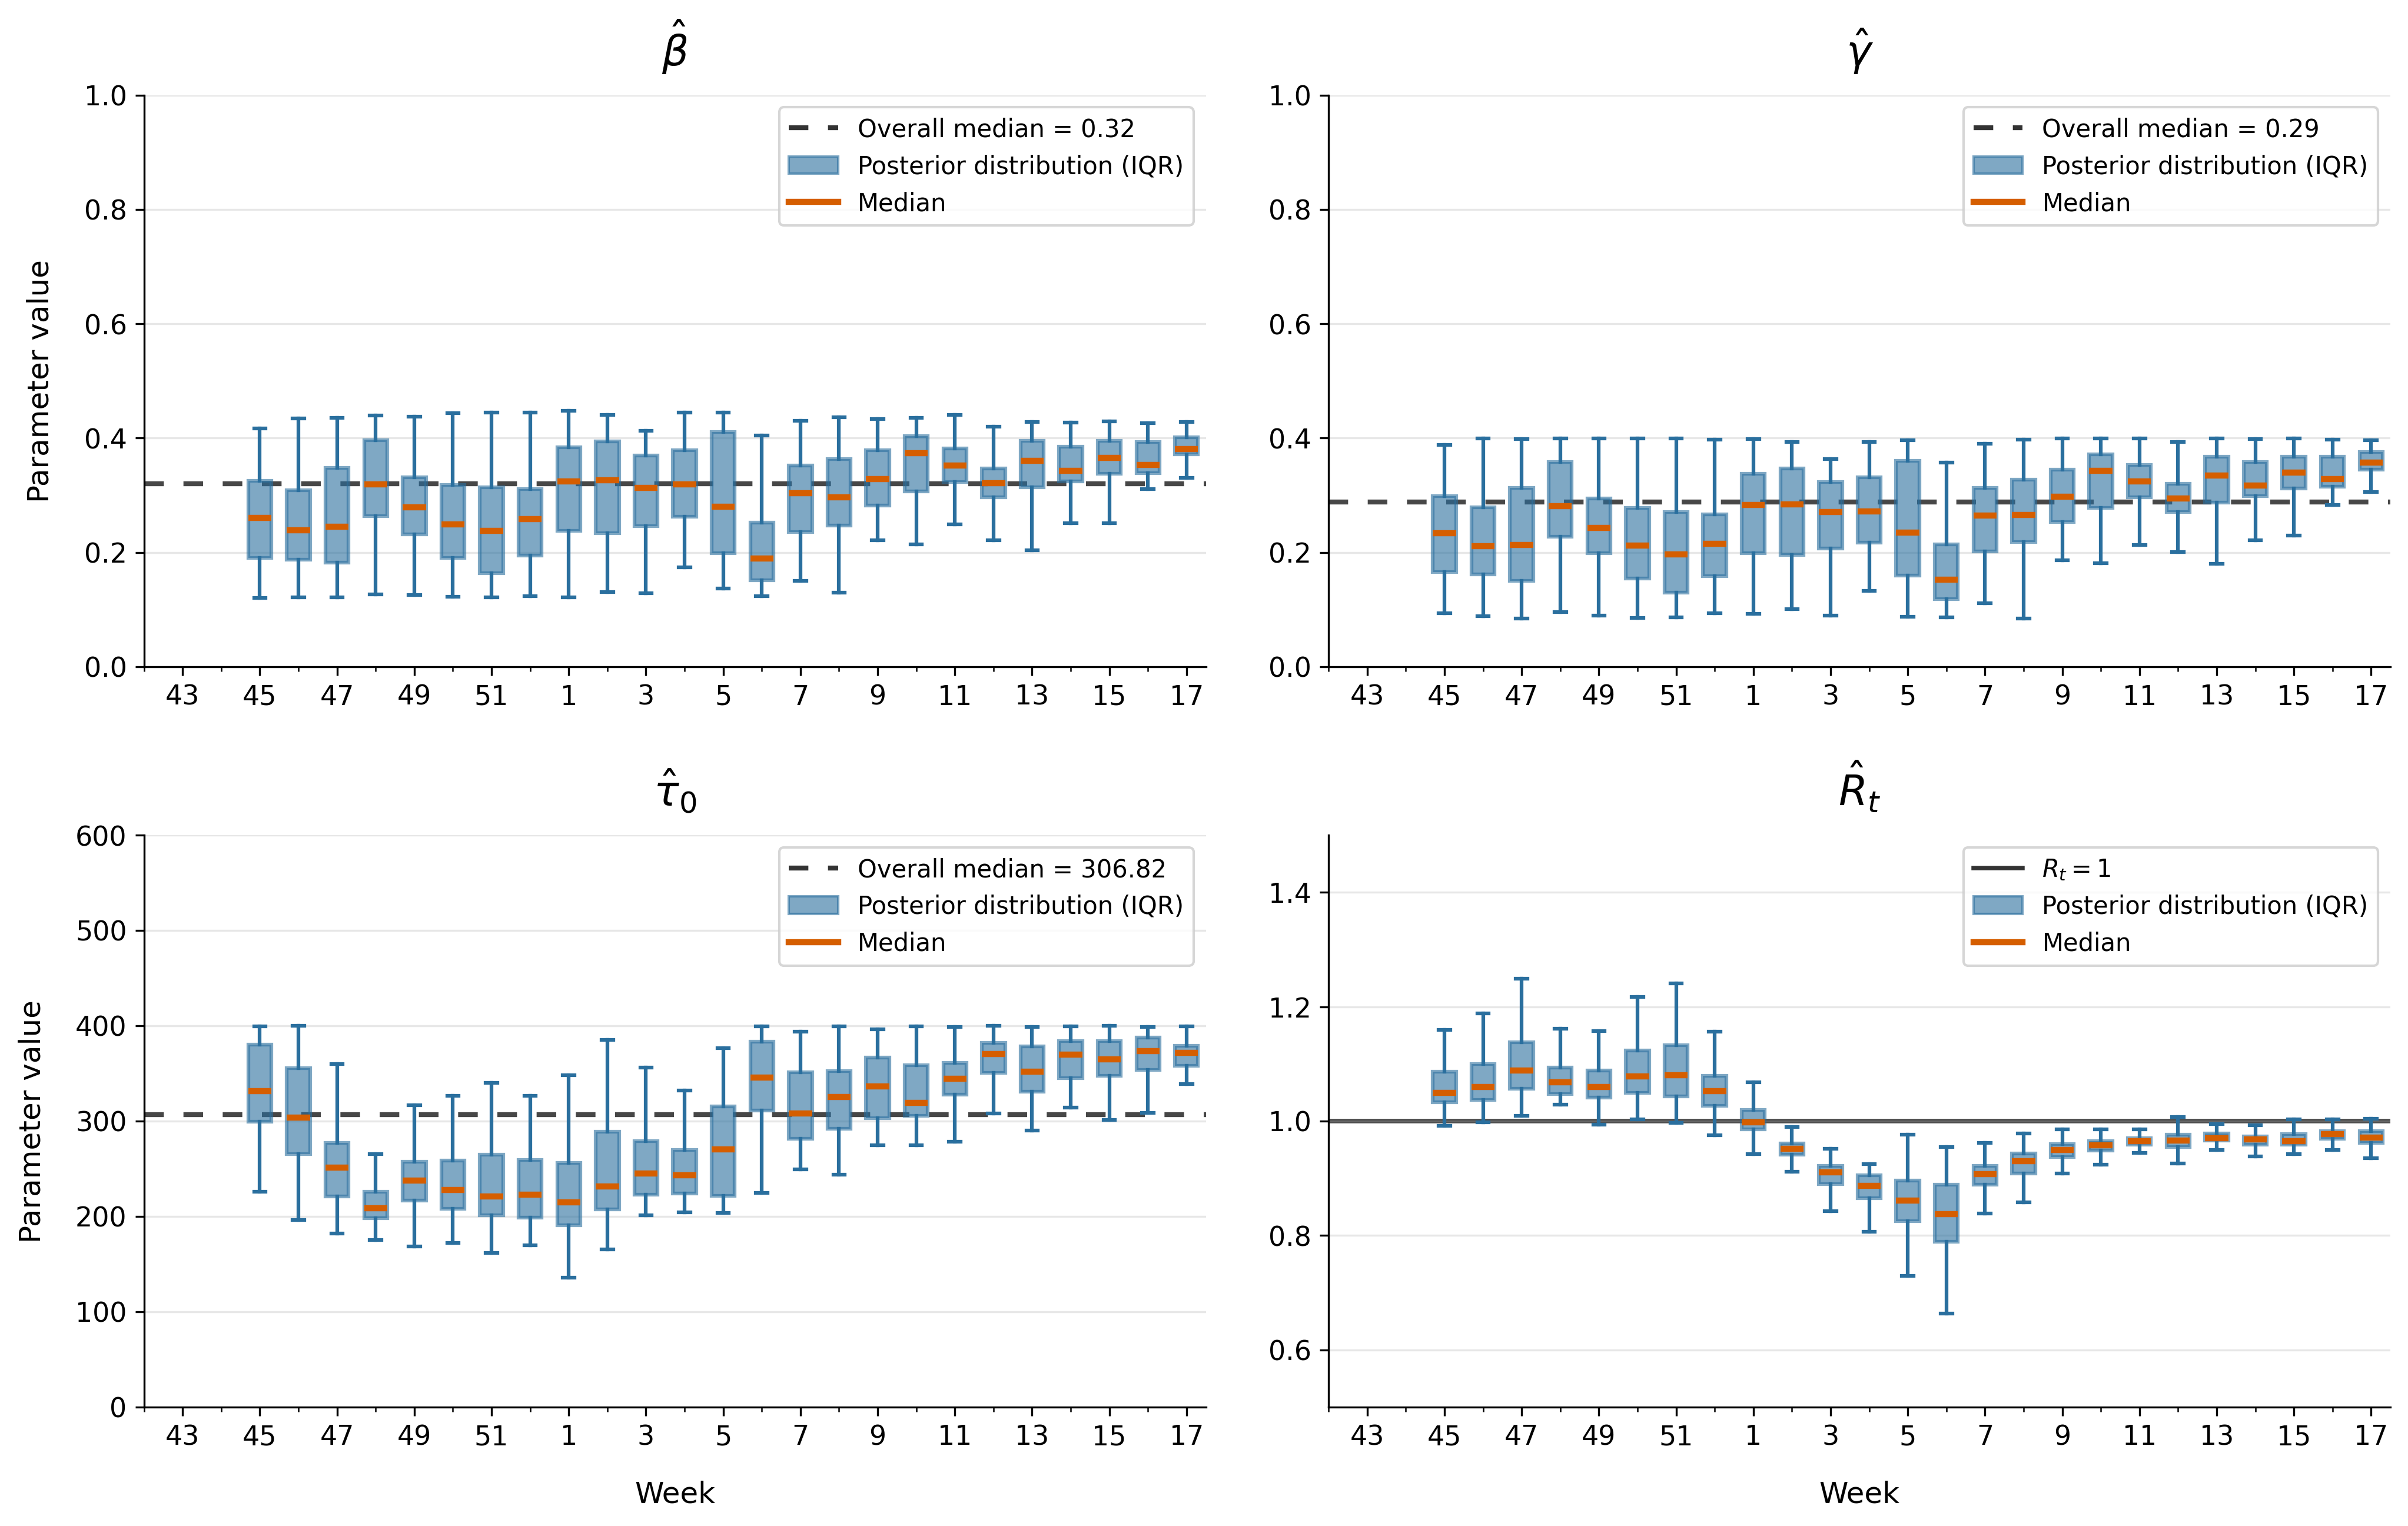

In [7]:
fig1 = plot_inferred_parameters(
    chains_dir=chains_dir
)

os.makedirs(f'../tmp_results/Plot/inference', exist_ok=True)
fig1.savefig(f"../tmp_results/Plot/inference/params_inference_{priors}_{season}.jpg", bbox_inches='tight',dpi=300)

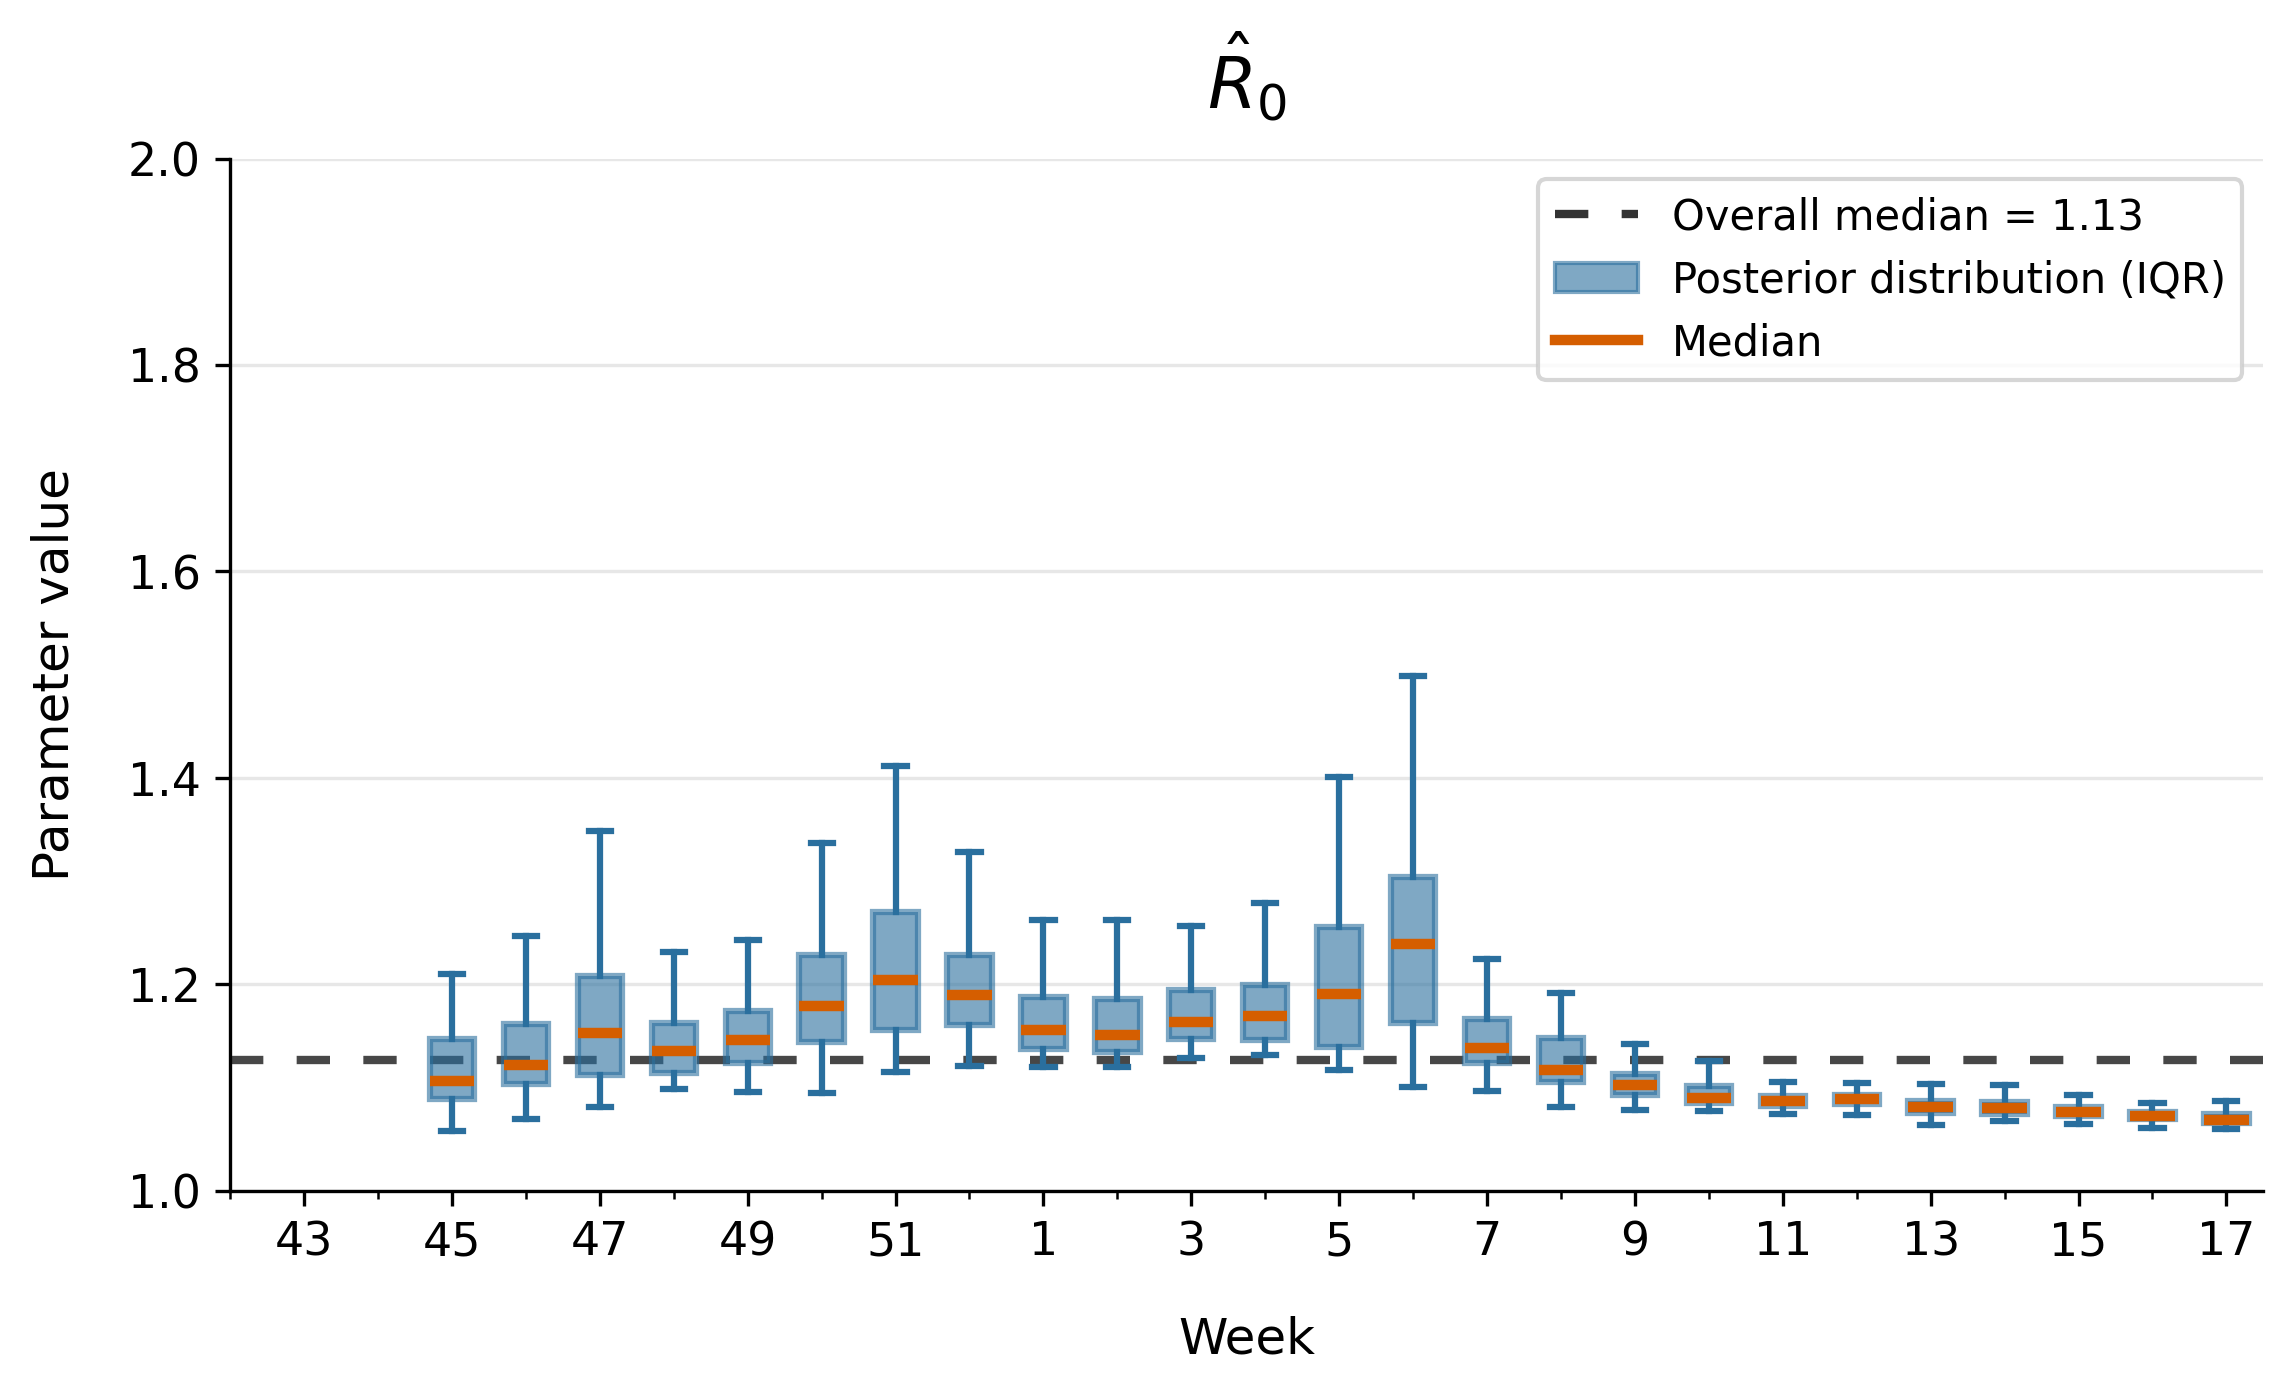

In [8]:
fig2 = plot_inferred_R0(
    chains_dir=chains_dir
)

os.makedirs(f'../tmp_results/Plot/inference', exist_ok=True)
fig2.savefig(f"../tmp_results/Plot/inference/params_inference_R0_{priors}_{season}.jpg",bbox_inches='tight',dpi=300)

### 4.2 Inferred parameters vs. training grid

To assess whether the inferred parameter pairs fall into the training domain, we show the weekly posterior medians of $\beta $ and $\gamma$ for each season onto the $(\beta,\gamma)$ grid used to generate the SIR-INN training dataset.
Points lying within the training cloud confirm that the model is operating in a well-covered region of the parameter space where SIR-INN accuracy is better.

In [9]:
# Load training data
x_train, y_train, idx_train = load_train_data("../data/SIR-INN_dataset.csv")

# Convert tensors to numpy arrays for plotting
x_train_np = x_train.detach().numpy()
y_train_np = y_train.detach().numpy()

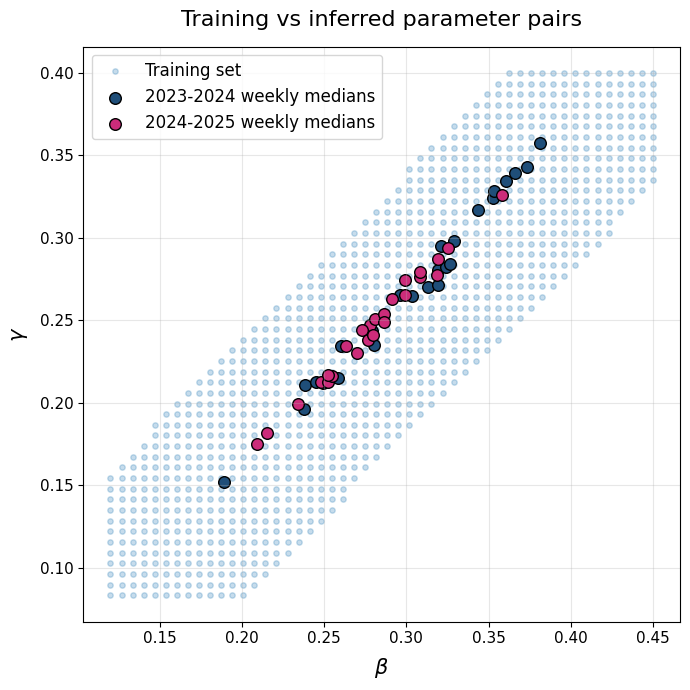

In [12]:
results_dir = rf"../tmp_results/"

fig3 = plot_training_set_with_parameters(
    x_train_np, 
    idx_train, 
    results_dir=results_dir
)

os.makedirs(f'../tmp_results/Plot/inference', exist_ok=True)
fig3.savefig(f'../tmp_results/Plot/inference/trainvsinfer_params.jpg', dpi=300, bbox_inches='tight')

Rolling-window MCMC inference has been completed for the selected influenza seasons.

At each epidemiological week (i.e., round), the posterior distributions of the transmission rate $\beta$, the recovery rate $\gamma$, the epidemic alligment time $\tau_0$, and the derived quantities $R_0$ and $R_t$ have been estimated using the pretrained SIR-INN as a forward model under a Poisson
likelihood.

Posterior samples have been aggregated and saved to `mcmc_distributions.pkl` within
each season's results directory. These will be loaded in `03_forecast.ipynb` to
generate probabilistic ILI incidence forecasts via posterior predictive propagation.